In [1]:
# mamba create -n somatic_paper pymc numpy pandas seaborn matplotlib arviz ipykernel openpyxl

In [2]:
import pymc as pm
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import arviz as az

for pkg in [pm, np, pd, sns, az]:
    print(f"{pkg.__name__} v{pkg.__version__}")

pymc v5.21.1
numpy v2.2.3
pandas v2.2.3
seaborn v0.13.2
arviz v0.21.0


In [3]:
muts_all = pd.read_csv("mut_counts_all.tsv", sep="\t")
sample_metadata = pd.read_csv("lcm_all_metadata_wVAF_wSensitivity.tsv", sep="\t")
sample_metadata.loc[sample_metadata.Patient.isin(["PD42775", "PD42776"]), "Patient"] = (
    "PD42773"
)
updated_metadata = pd.read_excel("SjD_pt_metadata.xlsx")

assert (
    set(sample_metadata[["Patient", "Diagnosis"]].apply(tuple, axis=1))
    - set(updated_metadata[["Patient", "Diagnosis"]].apply(tuple, axis=1))
) == {("PD45529", "Sjogrens"), ("PD45530", "Sjogrens")}

sample_metadata = pd.merge(
    sample_metadata,
    updated_metadata[["Patient", "Diagnosis"]],
    on="Patient",
    how="left",
    suffixes=("_old", ""),
)
sample_metadata = sample_metadata.drop(columns=["Diagnosis_old"])

assert set(sample_metadata[["Patient", "Diagnosis"]].apply(tuple, axis=1)) == set(
    updated_metadata[["Patient", "Diagnosis"]].apply(tuple, axis=1)
)

In [4]:
# Suppress SettingWithCopyWarning
pd.options.mode.chained_assignment = None  # default='warn'

# Filter samples based on Cell_type and Tissue
duct_samples = sample_metadata[sample_metadata["Cell_type"] == "Duct"]["Sample_ID"]
acini_samples = sample_metadata[sample_metadata["Cell_type"] == "Acinus"]["Sample_ID"]
lymphocyte_samples = sample_metadata[sample_metadata["Tissue"] == "Lymphocyte"][
    "Sample_ID"
]

# Filter metadata for Epithelium tissue
metadata_epi = sample_metadata[sample_metadata["Tissue"] == "Epithelium"]
metadata_epi["Diagnosis"] = metadata_epi["Diagnosis"].replace(
    {"Sjogrens": "PSS", "Non-Sjogrens": "Non-PSS"}
)

# Filter mutations for specific samples and conditions
mutations_epi = muts_all[
    (muts_all["Sample"].isin(duct_samples) | muts_all["Sample"].isin(acini_samples))
    & (muts_all["NV"] >= 3)
    & (muts_all["Depth"] >= 4)
]
mutations_epi["Patient"] = mutations_epi["Sample"].str[:7]

assert "Diagnosis" not in mutations_epi.columns
assert "Cell_type" not in mutations_epi.columns

old_shape = mutations_epi.shape[0]

# Add Diagnosis and Cell_type columns based on Sample
mutations_epi = pd.merge(
    mutations_epi,
    sample_metadata[["Sample_ID", "Diagnosis", "Cell_type"]],
    left_on="Sample",
    right_on="Sample_ID",
)

assert mutations_epi.shape[0] == old_shape

In [5]:
def logp_truncated_betabinom(value, n, alpha, beta, k):
    """
    Custom log-probability function for a left-truncated BetaBinomial distribution.

    Args:
        value: The observed data (must be > k).
        n: Number of trials.
        alpha: Alpha parameter of the Beta distribution.
        beta: Beta parameter of the Beta distribution.
        k: The truncation point (data is observed only if value > k).
    """
    if isinstance(k, (list, np.ndarray)):
        k = k[0]

    # Calculate the logp of the standard, non-truncated BetaBinomial
    logp_untruncated = pm.BetaBinomial.logp(value, n=n, alpha=alpha, beta=beta)

    # Calculate the log of the survival function at the truncation point: log(P(Y > k))
    # This is log(1 - CDF(k))
    # We use pm.math.log1mexp(log_cdf) for numerical stability, as it's better than log(1 - exp(log_cdf))
    log_survival = pm.math.log1mexp(
        pm.BetaBinomial.logcdf(k, n=n, alpha=alpha, beta=beta)
    )

    # The total logp is the sum of individual untruncated logps minus
    # the number of observations times the log of the normalization factor.
    total_logp = pm.math.sum(logp_untruncated) - value.shape[0] * log_survival

    return total_logp

In [6]:
import pymc as pm
import pytensor.tensor as pt


def logp_truncated_betabinom(value, n, alpha, beta, k):
    """
    Custom logp that manually calculates the log-CDF to avoid vectorization
    issues in the built-in pm.BetaBinomial.logcdf method.

    Args:
        value (tensor): The observed data tensor.
        n (tensor): The tensor for the number of trials.
        alpha (tensor): The tensor for the alpha parameter.
        beta (tensor): The tensor for the beta parameter.
        k (scalar): The integer truncation point (e.g., 2 for data > 2).
    """
    # 1. Calculate the logp for the observed data. This part works fine.
    logp_untruncated = pm.BetaBinomial.logp(value, n=n, alpha=alpha, beta=beta)

    # 2. Manually calculate the log-CDF at the truncation point k.
    # We will sum the probabilities for all integers from 0 to k.

    # Create a range of integers from 0 to k
    i_values = pt.arange(k[0] + 1)  # This will be a tensor [0, 1, 2] if k=2

    # Calculate the logp for each integer i in i_values.
    # The parameters n, alpha, and beta are vectors of length num_observations.
    # We broadcast them against i_values to get a matrix of logps.
    # The shape will be (k+1, num_observations).
    logp_at_i = pm.BetaBinomial.logp(i_values[:, None], n=n, alpha=alpha, beta=beta)

    # Use logsumexp to safely sum the probabilities in log-space along axis 0.
    # The result is a vector of log_cdf values, one for each observation.
    log_cdf = pm.math.logsumexp(logp_at_i, axis=0)

    # 3. Calculate the log of the survival function P(Y > k) = 1 - CDF(k)
    log_survival = pm.math.log1mexp(log_cdf)

    # 4. Apply the vectorized correction and sum to get the final logp
    total_logp = pt.math.sum(logp_untruncated - log_survival)

    return total_logp

In [7]:
def create_model(data: pd.DataFrame, category: str = "Cell_type", truncated=False):
    """
    Creates a PyMC model with coords and dims for hierarchical VAF analysis.

    Args:
        data: A pandas DataFrame with columns 'NV', 'Depth', 'sample_id', and
              a categorical column (e.g., 'cell_type' or 'diagnosis').
        category_name: The name of the categorical column to use
                       (e.g., 'cell_type' or 'diagnosis').  Defaults to 'cell_type'

    Returns:
        A PyMC model.
    """

    assert data.NV.min() >= 3, "Minimum NV must be 3."

    if category not in data.columns:
        raise ValueError(f"Column '{category}' not found in data.")

    # Define coordinates
    coords = {
        "Sample": data["Sample"].unique(),
        category: data[category].astype("category").cat.categories.to_list(),
        "obs_id": data.index.to_list(),
    }

    # Convert Category to numerical index (0 and 1)
    top_level_categories = data[category].astype("category").cat.categories
    category_codes = data[category].astype("category").cat.codes
    category_by_code = dict(enumerate(top_level_categories))
    code_by_category = {v: k for k, v in category_by_code.items()}
    n_categories = len(top_level_categories)

    # Convert Sample to numerical index
    sample_codes = data["Sample"].astype("category").cat.codes.to_numpy()
    n_samples = len(data["Sample"].unique())

    category_by_sample = (
        data.loc[:, ["Sample", category]].drop_duplicates()[category].to_numpy()
    )
    category_code_by_sample = np.array(
        [code_by_category[cat] for cat in category_by_sample]
    )

    with pm.Model(coords=coords) as model:
        # --- Level 4: Hyperpriors ---
        alpha_toplvl = pm.Exponential("alpha_toplvl", lam=1, dims=category)
        beta_toplvl = pm.Exponential("beta_toplvl", lam=1, dims=category)

        mu_eta = pm.Normal("mu_eta", mu=0, sigma=1, dims=category)
        sigma_eta = pm.HalfNormal("sigma_eta", sigma=1, dims=category)

        # --- Level 3: Cell-Type Level ---
        log_eta = pm.Normal(
            "log_eta",
            mu=mu_eta[category_code_by_sample],
            sigma=sigma_eta[category_code_by_sample],
        )
        eta = pm.Deterministic("eta", pm.math.exp(log_eta))

        mu = pm.Beta(
            "mu",
            alpha=alpha_toplvl[category_code_by_sample],
            beta=beta_toplvl[category_code_by_sample],
            dims="Sample",
        )

        # --- Level 1: Mutation Level (Likelihood) ---
        if truncated:
            # --- Level 2: Sample Level ---
            alpha = pm.Deterministic("alpha", mu * eta)
            beta = pm.Deterministic("beta", (1 - mu) * eta)
            truncation_point = 2

            likelihood = pm.CustomDist(
                "NV",
                data["Depth"],
                alpha[sample_codes],
                beta[sample_codes],
                truncation_point,
                logp=logp_truncated_betabinom,
                observed=data["NV"],
            )
        else:
            # --- Level 2: Sample Level ---
            alpha = pm.Deterministic("alpha", mu * eta)
            beta = pm.Deterministic("beta", (1 - mu) * eta)

            likelihood = pm.BetaBinomial(
                "NV",
                n=data["Depth"],
                alpha=alpha[sample_codes],
                beta=beta[sample_codes],
                observed=data["NV"],
                dims="obs_id",
            )

        # --- Deterministic Variables for Visualization ---

        # Per-sample mean VAF (already have 'mu' from Level 3)
        per_sample_mean_vaf = pm.Deterministic("VAF by Sample", mu)

        # Per-cell-type mean VAF
        mu_cell_type = pm.Deterministic(
            f"VAF by {category}", alpha_toplvl / (alpha_toplvl + beta_toplvl)
        )

        # Difference between cell type mean VAFs
        cat0 = top_level_categories[0]
        cat1 = top_level_categories[1]
        vaf_diff = pm.Deterministic(
            f"VAF_{cat1} - VAF_{cat0}", mu_cell_type[1] - mu_cell_type[0]
        )  # Assuming 0=Acinus, 1=Duct

        varnames_for_viz = [
            "VAF by Sample",
            f"VAF by {category}",
            f"VAF_{cat1} - VAF_{cat0}",
        ]
        model.varnames_for_viz = varnames_for_viz
    return model


# --- Example Usage (with dummy data) ---
def generate_dummy_data(n_samples_per_type=10, n_mutations_per_sample=20):
    rng = np.random.default_rng(42)

    data = []
    sample_id_counter = 0

    true_mu_samples = []  # Store true per-sample mu
    true_mu_cell_types = []  # Store true per-celltype mu

    for cell_type in ["Acinus", "Duct"]:
        if cell_type == "Acinus":
            true_mu_cell_types.append(rng.beta(2, 5))  # Beta(2,5) for Acinus
        else:
            true_mu_cell_types.append(rng.beta(5, 2))  # Beta(5, 2) for Duct

        for i in range(n_samples_per_type):
            diagnosis = ["PSS", "Non-PSS"][i % 2]  # Alternate between PSS and Non-PSS

            # Simulate sample-level parameters (simplified for demonstration)
            if cell_type == "Acinus":
                mu_sample = rng.beta(2, 5)  # Lower VAF on average
            else:
                mu_sample = rng.beta(5, 2)  # Higher VAF on average

            eta_sample = rng.exponential(10) + 2  # Ensure eta > 2

            alpha_sample = mu_sample * eta_sample
            beta_sample = (1 - mu_sample) * eta_sample

            true_mu_samples.append(mu_sample)  # Store the true sample mu

            for _ in range(n_mutations_per_sample):
                vaf = rng.beta(alpha_sample, beta_sample)
                depth = rng.integers(50, 200)  # Example depth range
                nv = rng.binomial(depth, vaf)
                data.append(
                    [nv, depth, f"Sample_{sample_id_counter}", cell_type, diagnosis]
                )
            sample_id_counter += 1

    df = pd.DataFrame(data, columns=["NV", "Depth", "Sample", "Cell_type", "Diagnosis"])
    df = df.drop(df[df["NV"] < 3].index)
    true_vaf_diff = true_mu_cell_types[1] - true_mu_cell_types[0]  # True difference
    return df, np.array(true_mu_samples), np.array(true_mu_cell_types), true_vaf_diff


In [8]:
# # --- Run the Model and Visualize ---
# for category in ["Cell_type", "Diagnosis"]:
#     model = create_model(mutations_epi, category=category, truncated=False)

#     with model:
#         approx = pm.fit(random_seed=42)
#         # Sample from the approximation 5 times and concatenate along "chain" dimension
#         idata_list = [approx.sample(draws=2500) for _ in range(5)]
#         idata = az.concat(idata_list, dim="chain")
#     idata.to_netcdf(f"{category}_posterior_approx_25092901.nc")

In [9]:
# # --- Run the Model and Visualize ---
# for category in ["Cell_type", "Diagnosis"]:
#     model = create_model(mutations_epi, category=category, truncated=True)

#     with model:
#         idata = pm.sample(
#             2500, tune=2000, chains=5, cores=5, random_seed=42, target_accept=0.95
#         )
#     idata.to_netcdf(f"{category}_posterior_trunc_25092901.nc")

In [10]:
# # --- Run the Model and Visualize ---
# for category in ["Diagnosis", "Cell_type"]:
#     model = create_model(mutations_epi, category=category, truncated=False)

#     with model:
#         idata = pm.sample(
#             2500, tune=2000, chains=4, cores=4, random_seed=42, target_accept=0.95
#         )
#     idata.to_netcdf(f"{category}_posterior_25092901.nc")

In [11]:
# --- Run the Model and Visualize ---
for category in ["Cell_type"]:  #, "Diagnosis"]:
    model = create_model(mutations_epi, category=category, truncated=False)

    with model:
        idata = pm.sample(
            2500, tune=2000, chains=4, cores=4, random_seed=42, target_accept=0.95
        )
    idata.to_netcdf(f"{category}_posterior_25092901.nc")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_toplvl, beta_toplvl, mu_eta, sigma_eta, log_eta, mu]


Output()

Sampling 4 chains for 2_000 tune and 2_500 draw iterations (8_000 + 10_000 draws total) took 8044 seconds.


In [ ]:
# --- Run the Model and Visualize ---
category = "Cell_type"
data_dummy, true_mu_samples, true_mu_cell_types, true_vaf_diff = generate_dummy_data(
    n_samples_per_type=10, n_mutations_per_sample=20
)

# model_dummy = create_model(data_dummy, category=category, truncated=True)

# with model_dummy:
#     idata_dummy = pm.sample(
#         1000, tune=1000, chains=4, cores=4, random_seed=42, target_accept=0.9
#     )

model = create_model(mutations_epi, category=category, truncated=False)

with model:
    idata = pm.sample(
        2500, tune=2000, chains=5, cores=5, random_seed=42, target_accept=0.95
    )
idata.to_netcdf("cell_type_posterior_25092901.nc")

# # idata = az.from_netcdf('cell_type_posterior_25031601.nc')
# # with model:
# #     idata = pm.sample(
# #         500, target_accept=0.95, start_from_trace=idata
# #     )

# idata.to_netcdf('cell_type_posterior_25031701.nc')

In [ ]:
model_diagnosis = create_model(mutations_epi, category="Diagnosis", truncated=False)
with model_diagnosis:
    idata_diagnosis = pm.sample(
        2500, tune=2000, chains=5, cores=5, random_seed=42, target_accept=0.95
    )
idata_diagnosis.to_netcdf("diagnosis_posterior_25092901.nc")

# idata_diagnosis = az.from_netcdf('diagnosis_posterior_25031701.nc')
# with model_diagnosis:
#     idata_diagnosis = pm.sample(
#         500, target_accept=0.95, start_from_trace=idata_diagnosis
#     )

# idata_diagnosis.to_netcdf("diagnosis_posterior_25031702.nc")

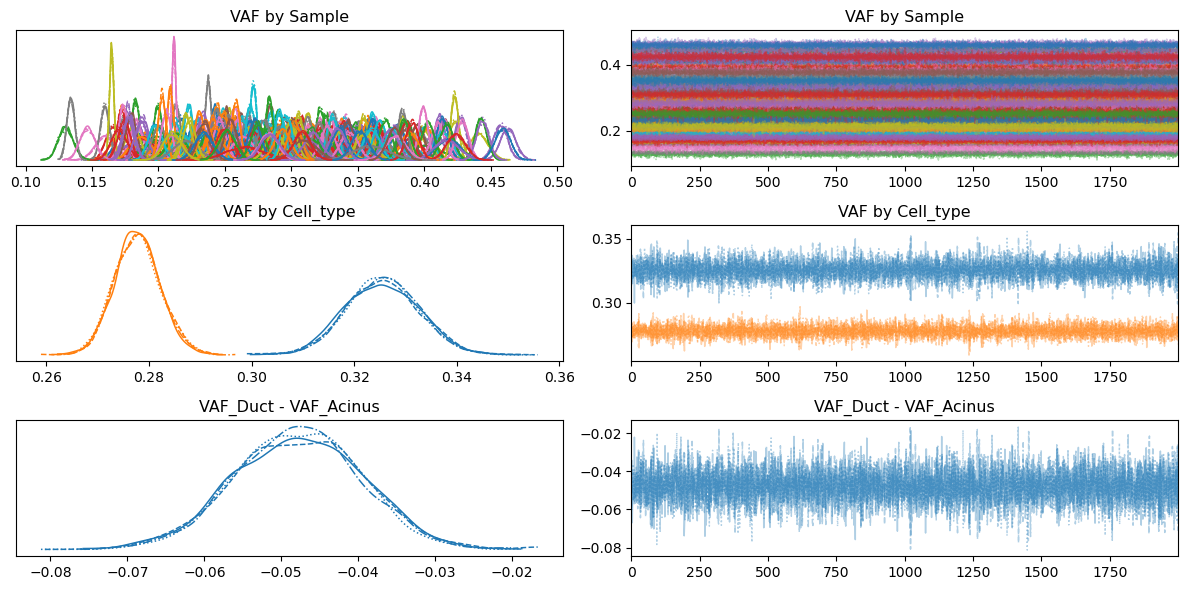

In [ ]:
az.plot_trace(idata, var_names=["VAF"], filter_vars="like", divergences=False)

plt.tight_layout();